# Klasyfikacja zdjęć RTG płuc
## Wykrywanie zapalenia płuc przy pomocy sieci neuronowej

Cel: klasyfikacja binarna zdjęć RTG na dwie klasy:
- NORMAL -> zdrowe płuca
- PHEUMONIA -> zapalenie płuc

https://www.learnpytorch.io/03_pytorch_computer_vision/

## 1. Importy

- torch / torch.nn - budowa i trening sieci neuronowej
- torchvision - datasety i transformacje obrazów
- matplotlib - wizualizacja obrazów

In [14]:
import torch
import torch.nn as nn


from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt

## 2. Konfiguracja 

Parametry i ścieżki

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (64, 64)
device = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_PATH = r'./dataset/chest_xray/train'
TEST_PATH  = r'./dataset/chest_xray/test'
VAL_PATH   = r'./dataset/chest_xray/val'


print(device)

co używa: cuda


## 3. Transformacje i datasety

ImageFolder automatycznie skanuje podfoldery i przypisuje etykiety alfabetycznie: 
NORMAL -> 0, PNEUMONIA -> 1

In [ ]:
data_trans = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Grayscale(1), #Automatycznie było w RGB 3 kanały zmieniłem na grayscale skoro i tak miały tą samą wartość
    transforms.ToTensor()
])

train_dataset = ImageFolder(TRAIN_PATH, transform=data_trans)
test_dataset  = ImageFolder(TEST_PATH,  transform=data_trans)
val_dataset   = ImageFolder(VAL_PATH,   transform=data_trans)

## 4. DataLoadery 

Opakowuje dane i dostarcza dane w batchach(paczkach)
Shuffle = True dla treningu - losuje kolejność batchy żeby model nie uczył się kolejności obrazów

In [17]:
train_loader = DataLoader(train_dataset, 
                          batch_size=BATCH_SIZE, #ile obrazów na batch 
                          shuffle=True #potasuj po epoce
                          )
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 5. Eksploracja datasetu

- Jakie klasy są w datasecie i ile obrazów ?

In [18]:
print(f"Klasy: {train_dataset.classes}")
print(f"Liczba obrazów - train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")
print(f"Batche w train_loader: {len(train_loader)}")

Klasy: ['NORMAL', 'PNEUMONIA']
Liczba obrazów - train: 5216, val: 16, test: 624
Batche w train_loader: 163


## 6. Podgląd batcha

In [19]:
# next(iter(...)) pobiera PIERWSZY batch bez pętli
images_batch, labels_batch = next(iter(train_loader))
print(f"Shape batcha obrazów: {images_batch.shape}")  # [32, 1, 512, 512] 32 - batch size(32 obrazy na raz) 1 bo grayscale
print(f"Shape batcha etykiet: {labels_batch.shape}")  # [32]

Shape batcha obrazów: torch.Size([32, 1, 64, 64])
Shape batcha etykiet: torch.Size([32])


## 7. Wizualizacja losowego obrazu

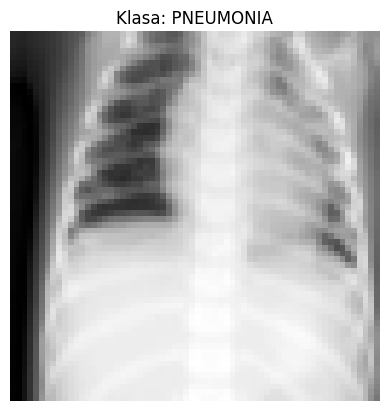

In [20]:
idx = torch.randint(0, BATCH_SIZE, (1,)).item()
img, label = images_batch[idx], labels_batch[idx]

# PyTorch trzyma (C, H, W), matplotlib chce (H, W, C)
plt.imshow(img.permute(1, 2, 0), cmap='gray') # bo zmieniłem na 1 kanał w transform 
plt.title(f"Klasa: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

## 8. nn.Flatten - co robi ?

Przed podaniem obrazu do warstwy liniowej (nn.Linear) musimy go spłaszycz z tensora 2D do wektora 1D

In [21]:
flatten_model = nn.Flatten()

x = images_batch[0]

output = flatten_model(x) #Forward pass

print(f"Shape przed {x.shape}")
print(f"Shape po {output.shape}")

Shape przed torch.Size([1, 64, 64])
Shape po torch.Size([1, 4096])


## 9. Baseline Model

In [22]:
class BaselineModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)